# Yield Curve Module 2: OIS Curve Construction

## 1. The EUR OIS Discount Curve -- Sources and Methods

The ESTR OIS discount curve is the standard discounting framework for
collateralised EUR derivatives (EMIR), IRRBB EVE calculations (EBA/RTS/2022/09),
and IFRS 13 fair value measurements. This notebook covers construction
from first principles and the practical data landscape.

---

### 1.1 Vendor Curves -- Production Standard

In a production environment the OIS curve is sourced directly from a
market data vendor. The curve is pre-bootstrapped, validated intraday,
and delivered via API or terminal. No construction required -- the desk
consumes discount factors directly.

**Bloomberg (BVAL / SWPM)**
The market standard for most banks and asset managers. The EUR ESTR OIS
curve is available under ticker `EUSA` (EUR OIS swap curve) in SWPM.
Discount factors can be extracted programmatically via the Bloomberg API
(BLPAPI) using the `YCGT0016 Index` curve identifier. Intraday updates,
full tenor coverage 1D to 50Y, validated against LCH clearing prices.

**Refinitiv Eikon / LSEG**
Available via the `EUR_ESTR_OIS` curve object in Eikon. Accessible
programmatically via the Refinitiv Data Library (RDP API). Similar
coverage to Bloomberg, slightly different interpolation methodology.
LSEG also publishes FTSE Term ESTR -- a forward-looking benchmark
derived from OIS quotes sourced from Tradeweb and LCH executed trades.

Both vendors source OIS quotes from inter-dealer brokers (Tradition,
ICAP, BGC) and LCH cleared trade data, bootstrap to discount factors
using log-linear interpolation on discount factors, and publish
intraday with timestamps.

---

### 1.2 Bootstrapping from Market Instruments -- Standard Method

When vendor curves are unavailable, the curve is constructed from
observable market instruments in three maturity zones:

**Short end: ESTR overnight fixing (ECB SDW)**
The overnight ESTR fixing published daily by the ECB anchors the curve
at T=0. Available free via the ECB Statistical Data Warehouse API.
Covers the overnight node only -- no term structure.

**Belly: ESTR futures (Eurex)**
Three-Month ESTR Futures (FST3) on Eurex provide implied forward rates
from 3 months to approximately 3 years via the quarterly IMM strip.
End-of-day settlement prices are published free on the Eurex website.
Each futures price implies a 3-month forward rate:

$$r_{fwd}(T_1, T_2) = 100 - Price$$

A convexity adjustment is required to convert from futures rates to
equivalent FRA rates, particularly beyond 1 year:

$$r_{FRA} = r_{futures} - \frac{1}{2}\sigma^2 T_1 T_2$$

Where $\sigma$ is the rate volatility over the contract period.

**Long end: ESTR OIS swaps**
Par OIS swap rates anchor the long end from 1Y to 30Y. Each par swap
rate implies a discount factor via the bootstrapping recursion:

$$P(0, T_n) = \frac{1 - s_n \sum_{i=1}^{n-1} \delta_i P(0, T_i)}{1 + s_n \delta_n}$$

Where $s_n$ is the par OIS swap rate and $\delta_i$ is the day count
fraction for period $i$. This is solved sequentially from short to long
maturities -- each new discount factor uses all previously solved ones.

---

### 1.3 Alternative Methods -- Free Data Approaches

When neither vendor curves nor clean futures/swap quotes are available,
two approaches provide workable approximations:

**ECB MMSR OIS Weighted Average Rates**

The ECB Money Market Statistical Reporting (MMSR) dataset collects all
wholesale OTC transactions reported by European banks under EU/2016/867.
The OIS sub-dataset reports weighted average fixed rates on actual
executed ESTR OIS trades aggregated into maturity buckets:

| Bucket | Series code | Rate 24-Mar-2026 |
|--------|-------------|-----------------|
| 1 month | MMSR...FC... | 1.94% |
| 2 months | MMSR...FD... | 1.96% |
| 3 months | MMSR...FE... | 1.99% |
| 6 months | MMSR...FF... | 2.07% |
| 9 months | MMSR...FG... | 2.01% |
| 2 years | MMSR...FI... | 2.18% |
| 3 years | MMSR...FJ... | 2.23% |
| 5 years | MMSR...FK... | 2.35% |
| 10 years | MMSR...FM... | 2.91% |

These are genuine executed OIS transactions -- not indicative quotes --
making them methodologically superior to broker snapshots. The limitation
is that rates are bucket averages rather than fixed tenor par rates, and
the dataset is published with a lag of approximately three weeks.

This is the approach implemented in this notebook.

**EURIBOR Swaps Adjusted for Basis**

An alternative proxy uses EURIBOR 3M swap rates from public sources
(Chatham Financial, Reuters) adjusted downward by the EURIBOR-ESTR
basis spread. The basis reflects the credit and liquidity premium
embedded in EURIBOR relative to the overnight risk-free rate:

$$r_{OIS}(T) \approx r_{EURIBOR\_swap}(T) - basis(T)$$

The basis is tenor-dependent -- typically 10-15bps at 2Y, widening
to 20-25bps at 10Y in the current market environment. The ECB publishes
indicative basis spreads via the MMSR dataset. This approach introduces
model risk from the basis assumption and is not appropriate for
regulatory submissions but is adequate for internal risk monitoring
and portfolio analytics.

---

### 1.4 Approach in This Notebook

ECB MMSR OIS weighted average rates as primary data source -- genuine
executed transactions, freely available via the ECB SDW API, no vendor
dependency. Where MMSR data is unavailable for a specific tenor, linear
interpolation between adjacent buckets is applied.

The MMSR dataset publishes with approximately a 3-week lag. To maintain
a consistent valuation date, the ESTR overnight fixing is taken from the
same date as the MMSR term rates rather than today's fixing. Both the
OIS curve and the NSS government curve from Notebook 1 are evaluated at
this common valuation date, making the OIS-government spread comparison
meaningful.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from quant_risk.data.ecb import ECBClient, MMSR_OIS_BUCKETS

pd.set_option("display.float_format", "{:.6f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

client = ECBClient()
print("imports ok")
print(f"QuantLib version: {ql.__version__}")

imports ok
QuantLib version: 1.42.1


In [2]:
# MMSR OIS rates -- full term structure
ois_raw = client.get_ois_rates(last_n=5)
ois_today = ois_raw.iloc[-1].dropna()
ois_date  = pd.to_datetime(ois_raw.index[-1])

print(f"MMSR OIS rates (latest available: {ois_date.date()}):")
print(ois_today)

# ESTR overnight fixing -- matched to MMSR valuation date
estr_hist = client.get_overnight_rate(last_n=252)
estr_hist.index = pd.to_datetime(estr_hist.index)

if ois_date in estr_hist.index:
    estr_today = estr_hist.loc[ois_date]
    print(f"\nESTR fixing on {ois_date.date()}: {estr_today:.4f}%")
else:
    prior = estr_hist[estr_hist.index <= ois_date]
    estr_today = prior.iloc[-1]
    print(f"\nESTR fixing not available for {ois_date.date()}, "
          f"using {prior.index[-1].date()}: {estr_today:.4f}%")

print(f"\nValuation date: {ois_date.date()}")

MMSR OIS rates (latest available: 2026-03-24):
1M     1.940000
2M     1.955000
3M     1.990000
6M     2.073000
9M     2.014000
12M    2.044000
2Y     2.178000
3Y     2.232000
5Y     2.354000
10Y    2.634000
10Y+   2.911000
Name: 2026-03-24, dtype: float64

ESTR fixing on 2026-03-24: 1.9320%

Valuation date: 2026-03-24


## 2. OIS Curve Bootstrapping

The MMSR OIS rates are weighted average fixed rates on executed OIS
transactions by maturity bucket. The underlying instrument type is not
reported -- a 3M rate could reflect a direct OIS agreement or a
futures-related transaction. For tenors under 1Y this ambiguity is
immaterial: short OIS transactions settle as a single net payment at
maturity and a deposit approximation is structurally correct.

Beyond 1Y the instrument structure matters. Standard OIS swaps at 2Y
and beyond pay periodic fixed coupons against compounded ESTR -- the
overwhelming majority of OIS transactions at these maturities follow
this structure. Treating them as deposits ignores the coupon schedule
and breaks the bootstrapping recursion. The correct approach uses the
par swap relationship:

$$P(0, T_n) = \frac{1 - s_n \sum_{i=1}^{n-1} \delta_i P(0, T_i)}{1 + s_n \delta_n}$$

Each new discount factor is solved using all previously bootstrapped
ones -- the long end is not solved in isolation. This is what
`ql.OISRateHelper` implements. `ql.DepositRateHelper` at long tenors
skips this recursion entirely, producing a structurally incorrect curve.

Note that futures-implied rates additionally require a convexity
adjustment before entering the bootstrapping:

$$r_{FRA} = r_{futures} - \frac{1}{2}\sigma^2 T_1 T_2$$

This corrects for the daily margining of futures contracts relative to
equivalent FRA rates. Since our MMSR rates are OIS transaction averages
rather than futures prices, no convexity adjustment is applied here.
QuantLib implements this via `ql.OvernightIndexFutureRateHelper` when
futures are used as inputs.

Two curves are built and compared to quantify the structural error from
the deposit approximation at long tenors:

- Short end (ON -- 9M): `DepositRateHelper` in both curves
- Long end (2Y -- 10Y): `DepositRateHelper` in Curve A, `OISRateHelper` in Curve B

Curve B is the structurally correct implementation and is adopted as
the reference OIS discount curve for all subsequent calculations.

In [12]:
# -----------------------------------------------------------------------
# QuantLib setup -- common to both curves
# -----------------------------------------------------------------------
calendar   = ql.TARGET()
day_count  = ql.Actual360()
settlement = ql.Date(24, 3, 2026)
ql.Settings.instance().evaluationDate = settlement

estr_index = ql.Estr()

# all instruments with their rates and tenors
all_nodes = {
    "ON"   : (estr_today / 100,         ql.Period(1,  ql.Days)),
    "1M"   : (ois_today["1M"] / 100,    ql.Period(1,  ql.Months)),
    "2M"   : (ois_today["2M"] / 100,    ql.Period(2,  ql.Months)),
    "3M"   : (ois_today["3M"] / 100,    ql.Period(3,  ql.Months)),
    "6M"   : (ois_today["6M"] / 100,    ql.Period(6,  ql.Months)),
    "9M"   : (ois_today["9M"] / 100,    ql.Period(9,  ql.Months)),
    "12M"  : (ois_today["12M"] / 100,   ql.Period(12, ql.Months)),
    "2Y"   : (ois_today["2Y"] / 100,    ql.Period(2,  ql.Years)),
    "3Y"   : (ois_today["3Y"] / 100,    ql.Period(3,  ql.Years)),
    "5Y"   : (ois_today["5Y"] / 100,    ql.Period(5,  ql.Years)),
    "10Y"  : (ois_today["10Y"] / 100,   ql.Period(10, ql.Years)),
    "10Y+" : (ois_today["10Y+"] / 100,  ql.Period(15, ql.Years)),
}

short_nodes = ["ON", "1M", "2M", "3M", "6M", "9M", "12M"]
long_nodes  = ["2Y", "3Y", "5Y", "10Y", "10Y+"]

# -----------------------------------------------------------------------
# OIS curve -- structurally correct reference
# -----------------------------------------------------------------------
helpers_short = [
    ql.DepositRateHelper(
        ql.QuoteHandle(ql.SimpleQuote(rate)),
        tenor, 0, calendar,
        ql.ModifiedFollowing, False, day_count,
    )
    for label, (rate, tenor) in all_nodes.items()
    if label in short_nodes
]

helpers_long = [
    ql.OISRateHelper(
        2, tenor,
        ql.QuoteHandle(ql.SimpleQuote(rate)),
        estr_index,
    )
    for label, (rate, tenor) in all_nodes.items()
    if label in long_nodes
]

ois_curve = ql.PiecewiseLogLinearDiscount(
    settlement, helpers_short + helpers_long, day_count
)
ois_curve.enableExtrapolation()
print("OIS curve: DepositRateHelper (ON-12M) + OISRateHelper (2Y-15Y)")
print("Case A: OIS piecewise log-linear interpolation")

# -----------------------------------------------------------------------
# OIS curve -- monotone cubic interpolation (production grade)
# -----------------------------------------------------------------------
ois_curve_smooth = ql.PiecewiseNaturalLogCubicDiscount(
    settlement, helpers_short + helpers_long, day_count
)
ois_curve_smooth.enableExtrapolation()
print("Case B: OIS curve smooth built: natural log cubic interpolation on discount factors")

# -----------------------------------------------------------------------
# deposit approximation -- for comparison only
# -----------------------------------------------------------------------
helpers_deposit = [
    ql.DepositRateHelper(
        ql.QuoteHandle(ql.SimpleQuote(rate)),
        tenor, 0, calendar,
        ql.ModifiedFollowing, False, day_count,
    )
    for _, (rate, tenor) in all_nodes.items()
]

ois_curve_deposit_approx = ql.PiecewiseLogLinearDiscount(
    settlement, helpers_deposit, day_count
)
ois_curve_deposit_approx.enableExtrapolation()
print("Deposit appr: all DepositRateHelper (comparison only)")

# -----------------------------------------------------------------------
# comparison table -- all three curves
# -----------------------------------------------------------------------
print(f"\n{'Maturity':>10} {'OIS smooth':>12} {'OIS log-lin':>13} {'Deposit approx':>16} {'Smooth vs log-lin':>19} {'Smooth vs deposit':>19}")
print("-" * 93)
for label, bucket in MMSR_OIS_BUCKETS.items():
    dt      = calendar.advance(settlement, ql.Period(int(bucket.maturity * 12), ql.Months))
    zr_smo  = ois_curve_smooth.zeroRate(dt, day_count, ql.Continuous).rate() * 100
    zr_ois  = ois_curve.zeroRate(dt, day_count, ql.Continuous).rate() * 100
    zr_dep  = ois_curve_deposit_approx.zeroRate(dt, day_count, ql.Continuous).rate() * 100
    sp1     = (zr_smo - zr_ois) * 100
    sp2     = (zr_smo - zr_dep) * 100
    print(f"{label:>10} {zr_smo:>12.4f} {zr_ois:>13.4f} {zr_dep:>16.4f} {sp1:>19.2f} {sp2:>19.2f}")

OIS curve: DepositRateHelper (ON-12M) + OISRateHelper (2Y-15Y)
Case A: OIS piecewise log-linear interpolation
Case B: OIS curve smooth built: natural log cubic interpolation on discount factors
Deposit appr: all DepositRateHelper (comparison only)

  Maturity   OIS smooth   OIS log-lin   Deposit approx   Smooth vs log-lin   Smooth vs deposit
---------------------------------------------------------------------------------------------
        1M       1.9384        1.9384           1.9384                0.00                0.00
        2M       1.9517        1.9517           1.9517                0.00                0.00
        3M       1.9850        1.9850           1.9850                0.00                0.00
        6M       2.0621        2.0621           2.0621                0.00                0.00
        9M       1.9987        1.9987           1.9987                0.00                0.00
       12M       2.0231        2.0231           2.0231                0.00             

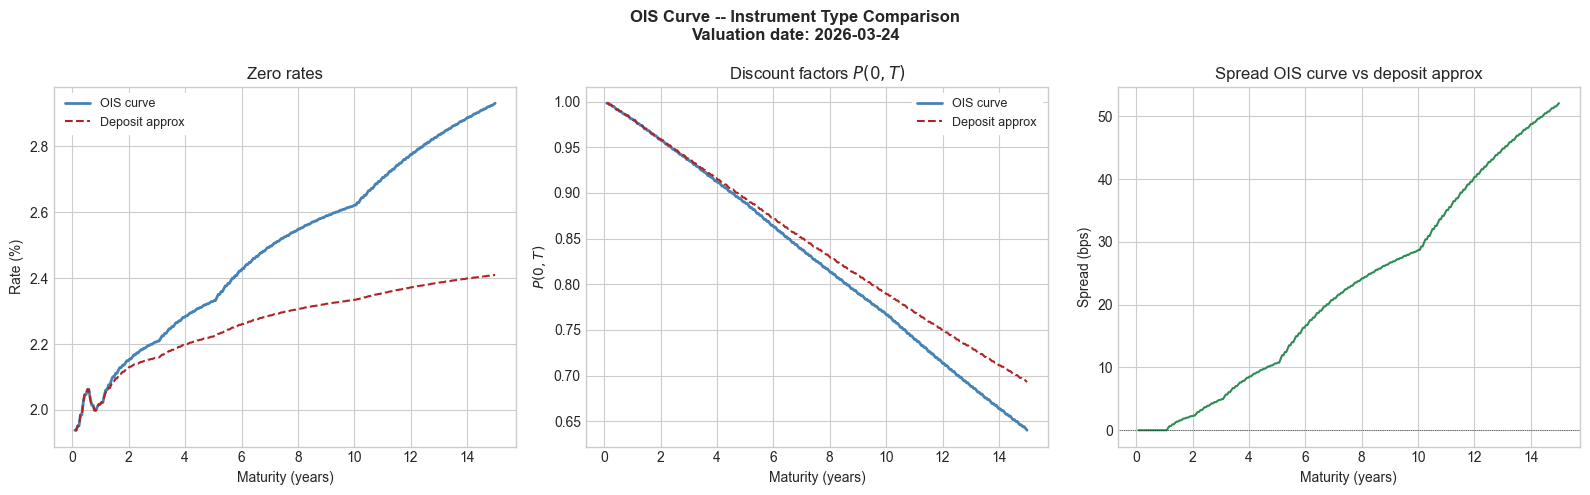

In [8]:
maturities_plot = np.linspace(1/12, 15, 300)

zr_ois_plot, zr_dep_plot, df_ois_plot, df_dep_plot = [], [], [], []

for y in maturities_plot:
    dt = calendar.advance(settlement, ql.Period(int(y * 12), ql.Months))
    zr_ois_plot.append(ois_curve.zeroRate(dt, day_count, ql.Continuous).rate() * 100)
    zr_dep_plot.append(ois_curve_deposit_approx.zeroRate(dt, day_count, ql.Continuous).rate() * 100)
    df_ois_plot.append(ois_curve.discount(dt))
    df_dep_plot.append(ois_curve_deposit_approx.discount(dt))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# zero rates
axes[0].plot(maturities_plot, zr_ois_plot,
             color="steelblue", linewidth=2, label="OIS curve")
axes[0].plot(maturities_plot, zr_dep_plot,
             color="firebrick", linewidth=1.5, linestyle="--",
             label="Deposit approx")
axes[0].set_title("Zero rates")
axes[0].set_ylabel("Rate (%)")
axes[0].set_xlabel("Maturity (years)")
axes[0].legend(frameon=True, facecolor="white",
               framealpha=1, edgecolor="white", fontsize=9)

# discount factors
axes[1].plot(maturities_plot, df_ois_plot,
             color="steelblue", linewidth=2, label="OIS curve")
axes[1].plot(maturities_plot, df_dep_plot,
             color="firebrick", linewidth=1.5, linestyle="--",
             label="Deposit approx")
axes[1].set_title("Discount factors $P(0,T)$")
axes[1].set_ylabel("$P(0,T)$")
axes[1].set_xlabel("Maturity (years)")
axes[1].legend(frameon=True, facecolor="white",
               framealpha=1, edgecolor="white", fontsize=9)

# spread
spread_plot = [(z1 - z2) * 100 for z1, z2 in zip(zr_ois_plot, zr_dep_plot)]
axes[2].plot(maturities_plot, spread_plot,
             color="seagreen", linewidth=1.5)
axes[2].axhline(0, color="black", linewidth=0.5, linestyle=":")
axes[2].set_title("Spread OIS curve vs deposit approx")
axes[2].set_ylabel("Spread (bps)")
axes[2].set_xlabel("Maturity (years)")

fig.suptitle(
    f"OIS Curve -- Instrument Type Comparison\n"
    f"Valuation date: {ois_date.date()}",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.show()